# Riemann Sums Trainer

This notebook teaches **numerical integration** using Riemann sums — the fundamental bridge between discrete computation and continuous integrals.

## Learning Objectives
- Connect definite integrals to area under a curve
- Implement left, right, midpoint, and trapezoid methods
- Analyze convergence rates as $n \to \infty$
- Understand error bounds for each method
- Implement Simpson's rule as an extension

## 1. Definite Integrals and Area

The definite integral of $f(x)$ from $a$ to $b$ is defined as the limit of Riemann sums:

$$\int_a^b f(x)\,dx = \lim_{n \to \infty} \sum_{i=0}^{n-1} f(x_i^*)\,\Delta x$$

where $\Delta x = (b - a)/n$ and $x_i^*$ is a sample point in the $i$-th subinterval $[x_i, x_{i+1}]$.

Different choices of $x_i^*$ give different methods:

| Method | Sample point $x_i^*$ | Error order |
|--------|---------------------|-------------|
| Left | $x_i$ | $O(1/n)$ |
| Right | $x_{i+1}$ | $O(1/n)$ |
| Midpoint | $(x_i + x_{i+1})/2$ | $O(1/n^2)$ |
| Trapezoid | avg of $f(x_i)$ and $f(x_{i+1})$ | $O(1/n^2)$ |
| Simpson's | weighted combination | $O(1/n^4)$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Test function: f(x) = x^2 on [0, 1]
# Exact integral = 1/3
def f(x):
    return x**2

exact_integral = 1.0 / 3.0
a, b = 0.0, 1.0

print(f"f(x) = x²")
print(f"Exact ∫₀¹ x² dx = {exact_integral:.10f}")

f(x) = x²
Exact ∫₀¹ x² dx = 0.3333333333


## 2. Implementing the Methods

In [2]:
def riemann_left(f, a, b, n):
    """Left Riemann sum."""
    dx = (b - a) / n
    total = 0.0
    for i in range(n):
        x = a + i * dx
        total += f(x) * dx
    return total

def riemann_right(f, a, b, n):
    """Right Riemann sum."""
    dx = (b - a) / n
    total = 0.0
    for i in range(n):
        x = a + (i + 1) * dx
        total += f(x) * dx
    return total

def riemann_midpoint(f, a, b, n):
    """Midpoint Riemann sum."""
    dx = (b - a) / n
    total = 0.0
    for i in range(n):
        x = a + (i + 0.5) * dx
        total += f(x) * dx
    return total

def riemann_trapezoid(f, a, b, n):
    """Trapezoidal rule."""
    dx = (b - a) / n
    total = 0.0
    for i in range(n):
        x_left = a + i * dx
        x_right = x_left + dx
        total += (f(x_left) + f(x_right)) / 2.0 * dx
    return total

# Test with n = 10
n = 10
print(f"n = {n}")
print(f"Left:      {riemann_left(f, a, b, n):.6f}  (error: {abs(riemann_left(f, a, b, n) - exact_integral):.6f})")
print(f"Right:     {riemann_right(f, a, b, n):.6f}  (error: {abs(riemann_right(f, a, b, n) - exact_integral):.6f})")
print(f"Midpoint:  {riemann_midpoint(f, a, b, n):.6f}  (error: {abs(riemann_midpoint(f, a, b, n) - exact_integral):.6f})")
print(f"Trapezoid: {riemann_trapezoid(f, a, b, n):.6f}  (error: {abs(riemann_trapezoid(f, a, b, n) - exact_integral):.6f})")

n = 10
Left:      0.285000  (error: 0.048333)
Right:     0.385000  (error: 0.051667)
Midpoint:  0.332500  (error: 0.000833)
Trapezoid: 0.335000  (error: 0.001667)


## 3. Visualizing the Rectangles

Let's draw the rectangles for each method to build geometric intuition:

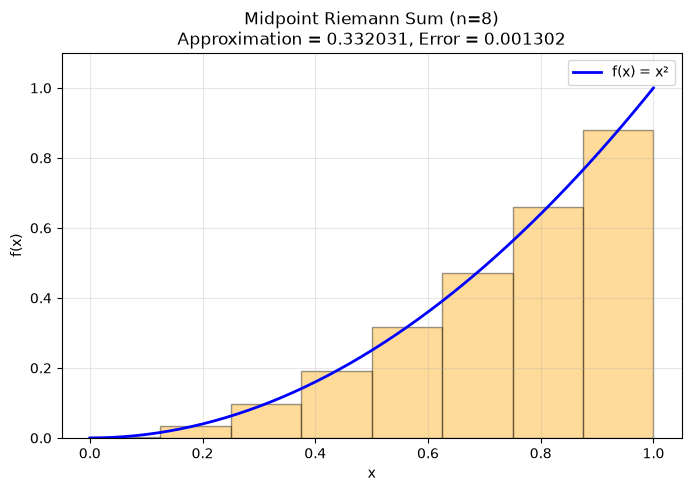

In [3]:
def plot_riemann(f, a, b, n, method='left'):
    """Visualize a Riemann sum with rectangles."""
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Plot the function
    x_fine = np.linspace(a, b, 200)
    ax.plot(x_fine, [f(x) for x in x_fine], 'b-', linewidth=2, label='f(x) = x²')
    
    dx = (b - a) / n
    total = 0.0
    
    for i in range(n):
        x_left = a + i * dx
        
        if method == 'left':
            height = f(x_left)
        elif method == 'right':
            height = f(x_left + dx)
        elif method == 'midpoint':
            height = f(x_left + dx/2)
        else:  # trapezoid
            height = (f(x_left) + f(x_left + dx)) / 2
        
        total += height * dx
        rect = patches.Rectangle(
            (x_left, 0), dx, height,
            linewidth=1, edgecolor='black',
            facecolor='orange', alpha=0.4
        )
        ax.add_patch(rect)
    
    error = abs(total - exact_integral)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'{method.capitalize()} Riemann Sum (n={n})\n'
                 f'Approximation = {total:.6f}, Error = {error:.6f}')
    ax.legend()
    ax.set_xlim(a - 0.05, b + 0.05)
    ax.set_ylim(0, f(b) * 1.1)
    ax.grid(True, alpha=0.3)
    return fig

fig = plot_riemann(f, 0, 1, 8, 'midpoint')
plt.show()

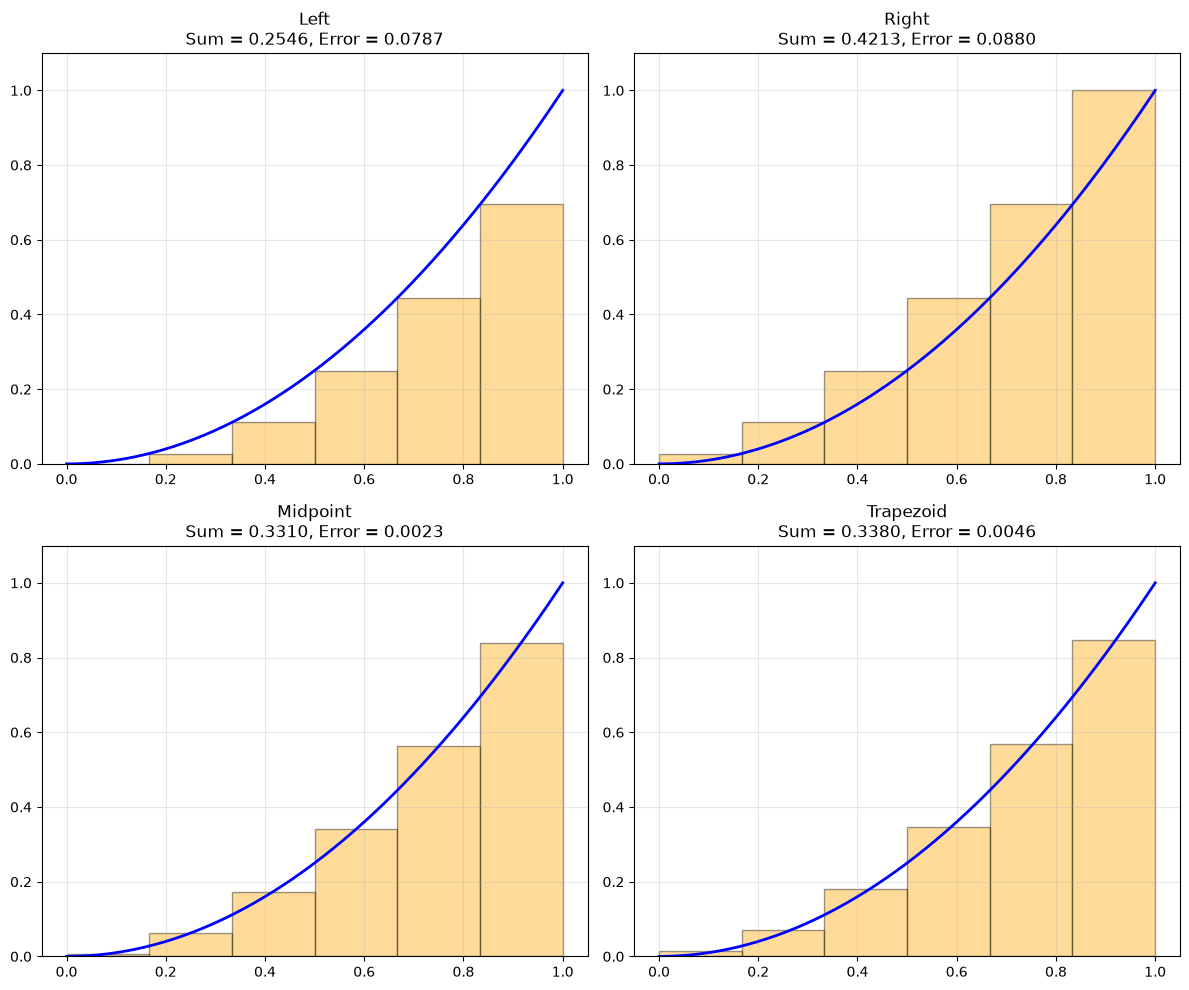

In [4]:
# Compare all four methods side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
methods = ['left', 'right', 'midpoint', 'trapezoid']
n_vis = 6

for ax, method in zip(axes.flat, methods):
    x_fine = np.linspace(a, b, 200)
    ax.plot(x_fine, [f(x) for x in x_fine], 'b-', linewidth=2)
    
    dx = (b - a) / n_vis
    total = 0.0
    for i in range(n_vis):
        x_left = a + i * dx
        if method == 'left':
            height = f(x_left)
        elif method == 'right':
            height = f(x_left + dx)
        elif method == 'midpoint':
            height = f(x_left + dx/2)
        else:
            height = (f(x_left) + f(x_left + dx)) / 2
        total += height * dx
        rect = patches.Rectangle(
            (x_left, 0), dx, height,
            linewidth=1, edgecolor='black', facecolor='orange', alpha=0.4
        )
        ax.add_patch(rect)
    
    error = abs(total - exact_integral)
    ax.set_title(f'{method.capitalize()}\nSum = {total:.4f}, Error = {error:.4f}')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Convergence Analysis

How fast does each method converge as we increase $n$?

- Left/Right: error $\sim O(1/n)$ — halving the error requires doubling $n$
- Midpoint/Trapezoid: error $\sim O(1/n^2)$ — halving the error requires $\sqrt{2} \times n$

Let's verify this empirically:

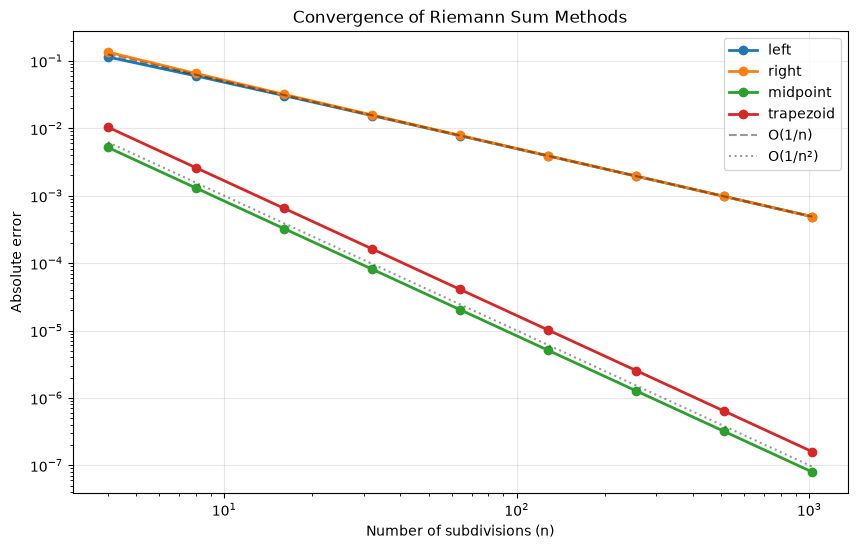

      left: avg convergence rate = 0.98
     right: avg convergence rate = 1.01
  midpoint: avg convergence rate = 2.00
 trapezoid: avg convergence rate = 2.00


In [5]:
n_values = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])

errors = {
    'left': [],
    'right': [],
    'midpoint': [],
    'trapezoid': [],
}

for n in n_values:
    errors['left'].append(abs(riemann_left(f, a, b, n) - exact_integral))
    errors['right'].append(abs(riemann_right(f, a, b, n) - exact_integral))
    errors['midpoint'].append(abs(riemann_midpoint(f, a, b, n) - exact_integral))
    errors['trapezoid'].append(abs(riemann_trapezoid(f, a, b, n) - exact_integral))

fig, ax = plt.subplots(figsize=(10, 6))

for method, errs in errors.items():
    ax.loglog(n_values, errs, 'o-', label=method, linewidth=2)

# Reference slopes
ax.loglog(n_values, 0.5 / n_values, 'k--', alpha=0.4, label='O(1/n)')
ax.loglog(n_values, 0.1 / n_values**2, 'k:', alpha=0.4, label='O(1/n²)')

ax.set_xlabel('Number of subdivisions (n)')
ax.set_ylabel('Absolute error')
ax.set_title('Convergence of Riemann Sum Methods')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Print convergence rates
for method, errs in errors.items():
    rates = np.log2(np.array(errs[:-1]) / np.array(errs[1:]))
    print(f"{method:>10}: avg convergence rate = {np.mean(rates):.2f}")

## 5. Error Analysis

The **error bounds** for smooth functions depend on the derivatives of $f$:

**Left/Right rule error:**
$$|E_n| \leq \frac{(b-a)^2}{2n} \max_{[a,b]} |f'(x)|$$

**Midpoint rule error:**
$$|E_n| \leq \frac{(b-a)^3}{24n^2} \max_{[a,b]} |f''(x)|$$

**Trapezoid rule error:**
$$|E_n| \leq \frac{(b-a)^3}{12n^2} \max_{[a,b]} |f''(x)|$$

Notice that midpoint is actually *twice as accurate* as trapezoid for the same $n$!

In [6]:
# For f(x) = x^2: f'(x) = 2x, f''(x) = 2
max_f_prime = 2.0 * b  # max |f'(x)| on [0,1] = 2
max_f_double_prime = 2.0  # f''(x) = 2 everywhere

print("Theoretical error bounds vs actual errors (n=100):")
print("="*55)

n_test = 100
dx = (b - a) / n_test

# Left/Right bound
bound_lr = (b - a)**2 / (2 * n_test) * max_f_prime
actual_left = abs(riemann_left(f, a, b, n_test) - exact_integral)
print(f"Left:      bound = {bound_lr:.6f}, actual = {actual_left:.6f}")

# Midpoint bound
bound_mid = (b - a)**3 / (24 * n_test**2) * max_f_double_prime
actual_mid = abs(riemann_midpoint(f, a, b, n_test) - exact_integral)
print(f"Midpoint:  bound = {bound_mid:.6f}, actual = {actual_mid:.6f}")

# Trapezoid bound
bound_trap = (b - a)**3 / (12 * n_test**2) * max_f_double_prime
actual_trap = abs(riemann_trapezoid(f, a, b, n_test) - exact_integral)
print(f"Trapezoid: bound = {bound_trap:.6f}, actual = {actual_trap:.6f}")

print(f"\nMidpoint/Trapezoid error ratio: {actual_mid/actual_trap:.3f} (theory predicts 0.5)")

Theoretical error bounds vs actual errors (n=100):
Left:      bound = 0.010000, actual = 0.004983
Midpoint:  bound = 0.000008, actual = 0.000008
Trapezoid: bound = 0.000017, actual = 0.000017

Midpoint/Trapezoid error ratio: 0.500 (theory predicts 0.5)


## 6. Using the `physics_modeling` Package

In [7]:
from physics_modeling.calculus.riemann import riemann_sum, RiemannResult

# Use the package implementation
result = riemann_sum(lambda x: x**2, 0.0, 1.0, 100, "midpoint")

print(f"Sum value: {result.sum_value:.10f}")
print(f"Reference integral: {result.reference_integral:.10f}")
print(f"Relative error: {result.relative_error:.2e}")
print(f"Rectangles shape: {result.rectangles.shape}")
print(f"First rectangle [x_left, width, height, x_sample]: {result.rectangles[0]}")

Sum value: 0.3333250000
Reference integral: 0.3333333333
Relative error: 2.50e-05
Rectangles shape: (100, 4)
First rectangle [x_left, width, height, x_sample]: [0.0e+00 1.0e-02 2.5e-05 5.0e-03]


In [8]:
# More interesting function: sin(x) on [0, pi]
# Exact integral = 2
import math

for n in [10, 50, 100, 500]:
    result = riemann_sum(math.sin, 0.0, math.pi, n, "trapezoid")
    print(f"n={n:>4}: sum = {result.sum_value:.8f}, "
          f"error = {abs(result.sum_value - 2.0):.2e}")

n=  10: sum = 1.98352354, error = 1.65e-02
n=  50: sum = 1.99934198, error = 6.58e-04
n= 100: sum = 1.99983550, error = 1.64e-04
n= 500: sum = 1.99999342, error = 6.58e-06


## Exercise: Implement Simpson's Rule

**Simpson's rule** uses a parabolic approximation on each pair of subintervals:

$$\int_a^b f(x)\,dx \approx \frac{\Delta x}{3}\left[f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \cdots + 4f(x_{n-1}) + f(x_n)\right]$$

where $n$ must be even. The error is $O(1/n^4)$ — much faster convergence!

**Tasks:**
1. Implement `simpsons_rule(f, a, b, n)` (require $n$ to be even)
2. Verify it gives exact results for polynomials up to degree 3 (why?)
3. Add it to the convergence plot — confirm the $O(1/n^4)$ slope
4. For $f(x) = e^{-x^2}$ on $[0, 3]$, how many subdivisions does each method need for 6-digit accuracy?

In [9]:
# Your Simpson's rule implementation here
def simpsons_rule(f, a, b, n):
    """Simpson's rule for numerical integration.
    
    Parameters
    ----------
    f : callable
        Function to integrate.
    a, b : float
        Integration bounds.
    n : int
        Number of subintervals (must be even).
    
    Returns
    -------
    float
        Approximate integral.
    """
    if n % 2 != 0:
        raise ValueError("n must be even for Simpson's rule")
    
    dx = (b - a) / n
    total = f(a) + f(b)
    
    for i in range(1, n):
        x = a + i * dx
        if i % 2 == 0:
            total += 2 * f(x)
        else:
            total += 4 * f(x)
    
    return total * dx / 3.0

# Test: should be exact for x^3
# ∫₀¹ x³ dx = 1/4
result = simpsons_rule(lambda x: x**3, 0, 1, 4)
print(f"Simpson's for x³ (n=4): {result:.10f} (exact: 0.25)")
print(f"Error: {abs(result - 0.25):.2e}")

# TODO: Add to convergence plot and find n needed for 6-digit accuracy

Simpson's for x³ (n=4): 0.2500000000 (exact: 0.25)
Error: 0.00e+00
